In [9]:
import numpy as np
import matplotlib.pyplot as plt

%config InlineBackend.figure_formats = ['svg']

import warnings
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", category=DeprecationWarning)

from IPython.core.display import HTML
HTML("""
<style>
.jp-RenderedImage{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
.jp-RenderedSVG{
    display: table-cell;
    text-align: center;
    vertical-align: middle;gr
}
.RenderedHTMLCommon{
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")



Table-lookup oscillators are essential in digital signal processing and audio synthesis. 
They are widely used to generate periodic waveforms such as sine, square, triangle, and sawtooth waves.
Beyond that, the method can be used to sythesize arbitrary waveforms, which is its key strength.


## Advantages

- **Efficiency**: By precomputing a waveform and storing it in a lookup table, the computation during runtime is minimal.
- **Flexibility**: The same framework can generate different waveforms - and thus any timbre - by using different tables.


## Drawbacks

- **Memory Usage:** This is usually not a problem, but the more precise a table lookup oscillator, the more memory it needs.
- **Distortion:** For small tables, this method creates distortions, more precisely quantization noise. For many applications, a well-designed table is accurate enough.


----

# The Lookup Table


**A lookup table is a sampled version of an arbitray continuous waveform.**
For basic periodic waveforms, the table holds exactly one cycle,
sometimes only half or the quarter of a cycle, making use of symmetries.
Table sizes of **256-4096 samples are common** in sound synthesis applications.

The following example of a sine wave table $T$ uses a smaller size of $N=32$ for more detailed visualization:



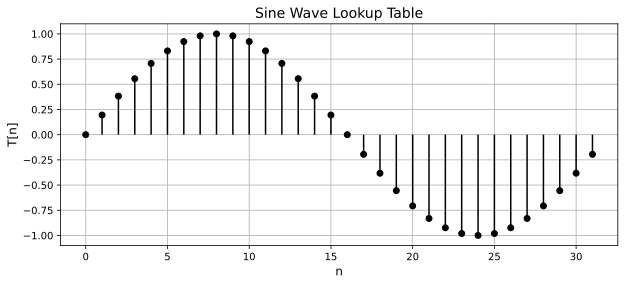

In [10]:



N = 32

def generate_sine_table(samples=N):
    """
    Generate a sine wave lookup table.
    :param samples: Number of samples in the table
    :return: Numpy array containing the sine wave table
    """
    return np.sin(2 * np.pi * np.arange(samples) / samples)

# Generate a sine lookup table
sine_table = generate_sine_table()

# Visualize the lookup table
plt.figure(figsize=(10, 4))
plt.stem(sine_table, label="Sine Wave Table",linefmt='k-', markerfmt='ko',basefmt=" ")
#plt.step(np.linspace(0,N-1,N), sine_table, label="Sine Wave Table", color='gray')
plt.axis('tight')
plt.title("Sine Wave Lookup Table", fontsize=14)
plt.xlabel("n", fontsize=12)
plt.ylabel("T[n]", fontsize=12)
#plt.legend(fontsize=12)
plt.grid(True)
plt.show()


-----

# Waveform Generation

This method in 3 steps ensures smooth waveform generation with high accuracy and efficiency, suitable for real-time audio or signal processing applications.

In [11]:
def phasor_lookup_visualization_with_phase(table, frequency, sample_rate, duration):
    """
    Generate a waveform using a lookup table with a phasor and visualize the phase progression.
    :param table: Lookup table (e.g., sine wave table)
    :param frequency: Frequency of the waveform in Hz
    :param sample_rate: Sampling rate in Hz
    :param duration: Duration of the waveform in seconds
    :return: Generated waveform, corresponding phasor values, and phase values (0 to 2pi)
    """
    table_size = len(table)
    total_samples = int(sample_rate * duration)
    phase_increment = frequency * table_size / sample_rate
    waveform = np.zeros(total_samples)
    phasor_values = np.zeros(total_samples)  # Store the phasor for visualization
    phase_values = np.zeros(total_samples)  # Store the phase (0 to 2pi)
    phase = 0

    for i in range(total_samples):
        # Get the integer and fractional parts of the phase
        index = int(phase) % table_size
        next_index = (index + 1) % table_size
        frac = phase - int(phase)

        # Linear interpolation
        waveform[i] = (1 - frac) * table[index] + frac * table[next_index]
        phasor_values[i] = phase % table_size  # Store the current phasor value
        phase_values[i] = (phase % table_size) * (2 * np.pi / table_size)  # Convert to radians
        phase += phase_increment
    
    return waveform, phasor_values, phase_values

# Parameters
frequency = 440  # Frequency in Hz
sample_rate = 48000  # Sampling rate in Hz
duration = 0.01  # Duration in seconds (shorter for visualization)

# Generate the waveform, phasor values, and phase values
waveform, phasor_values, phase_values = phasor_lookup_visualization_with_phase(sine_table, frequency, sample_rate, duration)

# Visualize the phase progression, phasor values, and resulting waveform
time = np.linspace(0, duration, len(waveform))


-----

## 1. **Phasor**
   - A phase accumulator that increments at a rate (`phase_increment`) that is defined by the table size and the desired frequency.   
   - This example uses the $2\pi$ range, known from trigonometric functions.
       - The phase wraps around cyclically when it reaches $2\pi$.

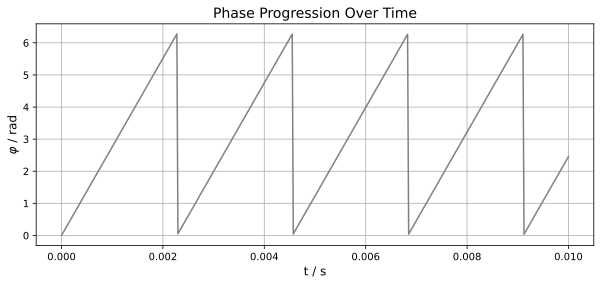

In [12]:
# Plot the phase progression (0 to 2pi)
plt.figure(figsize=(10, 4))
plt.plot(time, phase_values, label="Phase Progression (0 to 2π)", color="gray")
plt.title("Phase Progression Over Time", fontsize=14)
plt.xlabel("t / s", fontsize=12)
plt.ylabel("$\\varphi$ / rad", fontsize=12)
plt.grid(True)
#plt.legend(fontsize=12)

-----

## 2. **Phasor Scaling**

   - The phasor is scaled to the size of the lookup-table.
   - In this example it is cycling between the indexes 0 and 31.

For a sine wave at $f_0=440$ Hz with a table of size of $N=32$ samples and a sampling rate of $f_s=48$ kHz, the **sample-increment**  results in:

$$
\Delta_s = f_0  \frac{N}{f_s}
$$


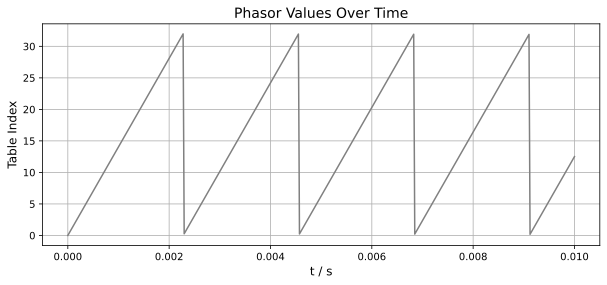

In [13]:
# Plot the phasor values
plt.figure(figsize=(10, 4))
plt.plot(time, phasor_values, label="Phasor (Table Index)", color="gray")
plt.title("Phasor Values Over Time", fontsize=14)
plt.xlabel("t / s", fontsize=12)
plt.ylabel("Table Index", fontsize=12)
plt.grid(True)
#plt.legend(fontsize=12)


## 3. **Table Lookup with Interpolation**:
   
   - The integer part of the phase determines the index in the table.
   - The fractional part of the phase is used for interpolation between the current and next index.
   - When the phasor lands between two indices in the table, linear interpolation is used to compute an in-between value.
   - This smooths out the waveform, especially for higher frequencies or low-resolution tables.

The interpolation is calculated with the lower and higher sample relative to the fractional position $p$ in the table.

We first get the lower and higher sample next to $p$:

$
p_l = ⌊p⌋
$

$
p_u = l+1
$

And the fractional value between these samples:

$
p_f = p - p_l
$

The fractional sample value is then obtained with linear interpolation:

$$
T(p) = (1 - p_f)  T[p_l] + p_f  T[p_u]
$$


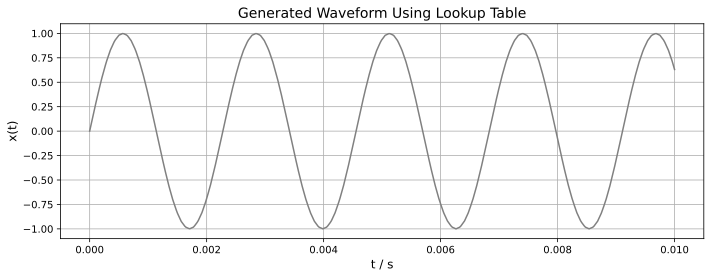

In [14]:
# Plot the waveform
plt.figure(figsize=(10, 4))
plt.plot(time, waveform, label="Generated Waveform", color="gray")
plt.title("Generated Waveform Using Lookup Table", fontsize=14)
plt.xlabel("t / s", fontsize=12)
plt.ylabel("x(t)", fontsize=12)
plt.grid(True)
#plt.legend(fontsize=12)

plt.tight_layout()
plt.show()

----

# Example 2: Frequency Modulation 

The following example shows how a sinewave with modulated frequency is created:



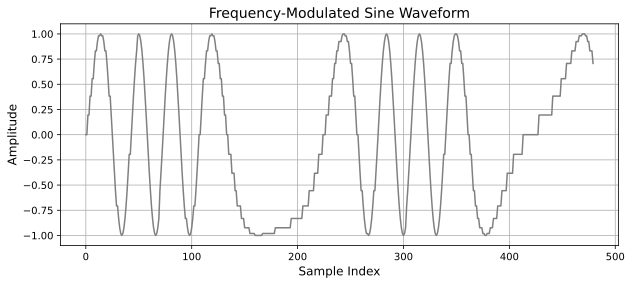

In [15]:
def fm_table_lookup_oscillator(table, carrier_freq, mod_freq, mod_index, sample_rate, duration):
    """
    Generate a frequency-modulated waveform using a table-lookup oscillator.
    :param table: Lookup table (e.g., sine wave table)
    :param carrier_freq: Carrier frequency in Hz
    :param mod_freq: Modulation frequency in Hz
    :param mod_index: Modulation index (depth of modulation)
    :param sample_rate: Sampling rate in Hz
    :param duration: Duration of the waveform in seconds
    :return: Generated waveform as a numpy array
    """
    table_size = len(table)
    total_samples = int(sample_rate * duration)
    carrier_increment = carrier_freq * table_size / sample_rate
    mod_increment = mod_freq * table_size / sample_rate
    waveform = np.zeros(total_samples)
    phase = 0
    mod_phase = 0

    for i in range(total_samples):
        mod_signal = table[int(mod_phase) % table_size]  # Modulation signal
        mod_phase += mod_increment
        phase_increment = carrier_increment + mod_signal * mod_index * table_size / sample_rate
        waveform[i] = table[int(phase) % table_size]
        phase += phase_increment

    return waveform

# Parameters for FM synthesis
carrier_freq = 840  # Carrier frequency in Hz
mod_freq = 200  # Modulation frequency in Hz
mod_index = 750  # Modulation index

# Generate frequency-modulated waveform
fm_waveform = fm_table_lookup_oscillator(sine_table, carrier_freq, mod_freq, mod_index, sample_rate, duration)

# Visualize the FM waveform (first 1000 samples)
plt.figure(figsize=(10, 4))
plt.plot(fm_waveform[:], label="Frequency-Modulated Sine Wave", color='gray')
plt.title("Frequency-Modulated Sine Waveform", fontsize=14)
plt.xlabel("Sample Index", fontsize=12)
plt.ylabel("Amplitude", fontsize=12)
#plt.legend(fontsize=12)
plt.grid(True)
plt.show()


----

# Efficiency 

## Efficiency of Lookup Table Oscillators
- A lookup table oscillator uses **precomputed values** stored in memory.
- Generating a waveform involves:
  - **Memory access**: Fetching a value from an array.
  - **Simple arithmetic**: Updating the phase index and performing modulo operations.
- These operations are computationally inexpensive compared to computing trigonometric functions.

---

## Efficiency of a `sin()` Function
- Computing the sine function (e.g., `sin()` in C++ or Python) involves:
  - **Trigonometric calculations**: Implementations use Taylor series, CORDIC algorithms, or similar methods.
  - These calculations require multiple multiplications, additions, and sometimes divisions, making them computationally expensive.

---

## Performance Comparison

- **Lookup Table Oscillator**: \( O(1) \) per sample (array lookup + basic arithmetic).
- **`sin()` Function**: \( O(n) \), where \( n \) depends on the precision required.

In real-world scenarios:

- A single `sin()` computation can take **50–150 nanoseconds** [1].
- A lookup table operation (memory access + arithmetic) might take **1–5 nanoseconds** [2][3].
- This results in **10–100x improvement** in speed for a lookup table oscillator.

----

- 1. Intel Developer Zone: *Optimizing Math Functions*  
   [https://www.intel.com/content/www/us/en/developer/articles/technical/optimizing-math-library.html](https://www.intel.com/content/www/us/en/developer/articles/technical/optimizing-math-library.html)
- 2. Real-Time DSP Guide: *Table Lookup Oscillators*  
   [https://www.dspguide.com/](https://www.dspguide.com/)
- 3. MusicDSP.org: *Wavetable Synthesis Techniques*  
   [https://musicdsp.org/](https://musicdsp.org/)

   
---

## Example 
Generating a sine wave at 44.1 kHz for 1 second:
- **Using `sin()`**:
  - Compute \( 44,100 \) sine values, each taking ~100 ns.
  - Total computation time: ~4.41 ms.
- **Using a Lookup Table**:
  - Perform \( 44,100 \) memory accesses and phase updates, each taking ~1–5 ns.
  - Total computation time: ~0.1 ms.

This shows a potential **40x improvement** in speed.


--- 
  
## Memory Usage

- Lookup tables require memory to store precomputed values:
  - Example: **A 1024-sample table of 32-bit floats requires 4 KB of memory.**
- Direct `sin()` does not need additional memory but uses more CPU cycles.


---



---

# Distortion and SNR


The Signal-to-Noise Ratio (SNR) and quantization noise for a table lookup sine oscillator depend on the table size **N**, which is the number of samples per cycle used in the lookup table. A larger table size improves the accuracy of the sine wave representation and thus reduces the quantization error (noise) and increases the SNR.

The Signal-to-Noise Ratio (SNR) for a table lookup sine oscillator is influenced by the size of the lookup table and the interpolation method used. Larger tables result in more accurate sine wave approximations, while interpolation techniques (like linear or cubic interpolation) reduce quantization noise, improving the overall SNR.
The quantization in the time domain has the same effect as a quantization in the amplitude range.

## Quantization Noise

The quantization noise (in dB) is inversely proportional to the table size **N**. It can be approximated as:

$$
\text{Noise (dB)} \approx -6.02 \cdot \log_2(N) \quad \text{dB}
$$

Where:

- **N** is the number of samples in the lookup table (the table size).
- The **quantization noise** decreases as the table size increases, following a logarithmic relationship.


## SNR Formula

### Basic SNR Formula:
The SNR for a table lookup sine oscillator can be approximated as:


$$
\text{SNR} ≈ 6.02⋅log2​(N)+constant
$$

Without interpolation this results in:

$$
\text{SNR} \approx 6.02 \cdot log2​(N) + 1.76 \quad \text{dB}
$$

----

### Effect of Interpolation:

- Lookup tables can use interpolation (e.g., linear or cubic) to improve accuracy, adding some computational overhead.
- Even with interpolation, lookup tables remain faster than direct computation.
- Without interpolation, the output waveform can sound rough or distorted, especially when the table resolution is low.
- Linear interpolation provides a balance between computational cost and accuracy.
- For even higher precision, cubic interpolation can be used, but at a greater computational expense.


**Linear interpolation** reduces the quantization noise compared to using no interpolation, improving the SNR by approximately **3 dB**.

Thus, the formula for SNR with **linear interpolation** becomes:

$$
\text{SNR}_{\text{linear}} = 6.02 \cdot \log_2(N) + 1.76 + 3 \quad \text{dB}
$$

For **higher-order interpolation** methods (e.g., cubic interpolation), the SNR improvement is even greater, but the improvement becomes less significant as the table size grows.



Where:

- **N** is the number of samples in the lookup table (the table size).
- The **3 dB** accounts for the improvement provided by linear interpolation over simple nearest-neighbor lookup.


The following plot shows the relation between table size and quantization noise, respectively SNR.
As the table size **N** increases, the **SNR** increases logarithmically while the **quantization noise** decreases logarithmically:


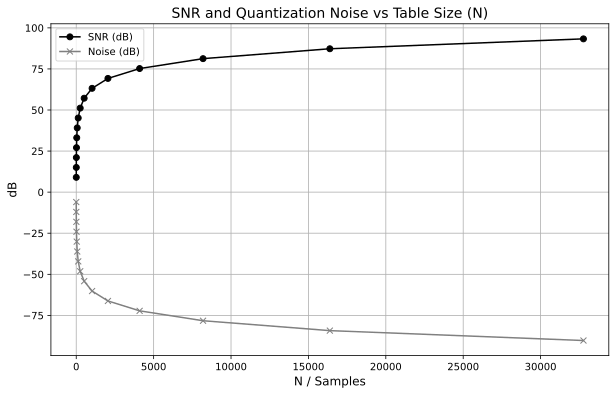

In [8]:
# Importing required libraries
import numpy as np
import matplotlib.pyplot as plt

# Function to calculate SNR (in dB)
def snr(N):
    return 6.02 * np.log2(N) + 3  # Linear interpolation assumption

# Function to calculate Noise (in dB)
def quantization_noise(N):
    return -6.02 * np.log2(N)  # Quantization noise formula

# Table sizes for demonstration
table_sizes = np.array([2**i for i in range(1, 16)])

# Calculate SNR and Noise for each table size
snr_values = snr(table_sizes)
noise_values = quantization_noise(table_sizes)

# Create a plot for SNR and Noise vs Table Size
plt.figure(figsize=(10, 6))
plt.plot(table_sizes, snr_values,   label ='SNR (dB)', color='black', linestyle='-', marker='o')
plt.plot(table_sizes, noise_values, label ='Noise (dB)', color='gray', linestyle='-', marker='x')

plt.xscale('linear')  # Log scale for better visualization
plt.yscale('linear')
plt.xlabel('N / Samples', fontsize=12)
plt.ylabel('dB', fontsize=12)
plt.title('SNR and Quantization Noise vs Table Size (N)', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()



 
-----


## Further Reading:

1. **Cook, P. R.** (1997). *Real Sound Synthesis for Interactive Applications*. CRC Press.
2. **Zucker, S. R., & Thorne, R.** (1995). *High-Quality Sound Generation: Using Lookup Tables and Interpolation for Accurate and Efficient Sound Synthesis*. Journal of the Audio Engineering Society, 43(6), 449–462.
3. **Allen, J. B., & Berkley, D. A.** (1979). *Image Method for Efficiently Simulating Small-room Acoustics*. Journal of the Audio Engineering Society, 27(6), 404–412.
4. **Gürbüz, O., & Remez, R.** (2004). *Efficient Implementation of Audio Signal Processing Techniques: A Lookup Table Approach*. IEEE Transactions on Audio, Speech, and Language Processing, 12(4), 301-309.

